# Project data exploration II -
## plotting categorical plot and incorporating other data

---


We will continue to work with the dataset that your group is consider for the term project. In this notebook we will create some plot using the Seaborn module and the different categorical plots we practiced in class. Additionally, we will explore the idea of working with other datasets in addition to the one you originally selected to strengthen your argument.

Group name: Group 15
Created by: Seven (Stephani) Soriano (ID: 018072470), Satyansh Rai (ID: 016323567), Karla Nguyen (ID: 017111185), Jay Barrios Abarquez (ID: 017694040)
Last updated: 3/27/2026

### Q1: How clean is your data?  
Do you have formatting concerns, null values, inconsistent data, etc... If so, explain what cleaning or reformating you have to do and how you plan to approach this cleaning steps.

We do have some concerns with our dataset, particularly with how it handled the prices.

First, the prices are written in cents, meaning the graph axis for price looks artificially inflated. Furthermore, there are some "gimmick" games that cost an absurd amount of money, skewing the data further.

Secondly, the dataset considers games that are "Free" as having Null prices rather than costing `$0`. To address all of these issues, we plan to divide the price columns by 100 to standardize it to dollars and filter any games that are out of a typical game's price range (this can be defined by the user later, but for now we want to set it to `$100`).

Finally, to address the null values, we plan to replace all Null prices for free games with `$0` so they can be accurately included in our dataset.

In [1]:
### Import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

### Import data
steam_games = pd.read_csv("steam_games_small.csv")

### Here are the steps for the cleaned data
steam_clean = steam_games.copy()
## Replace all null values (free games) with $0
steam_clean["mat_initial_price"] = steam_clean["mat_initial_price"].fillna(0)
steam_clean["mat_final_price"] = steam_clean["mat_final_price"].fillna(0)
## Convert prices from cents to dollars
steam_clean["mat_initial_price"] = steam_clean["mat_initial_price"] / 100
steam_clean["mat_final_price"] = steam_clean["mat_final_price"] / 100
## Remove games with prices over $100
steam_clean = steam_clean[
    (steam_clean["mat_initial_price"] <= 100) &
    (steam_clean["mat_final_price"] <= 100)
]
## Reset the index
steam_clean = steam_clean.reset_index(drop=True)

## Make sure the cleaning worked
steam_clean.info()

# ## Save to a new csv for future use (can leave commented out)
# steam_clean.to_csv("steam_clean_under_100.csv", index=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 238619 entries, 0 to 238618
Data columns (total 7 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   name                   238615 non-null  object 
 1   release_date           201832 non-null  object 
 2   mat_initial_price      238619 non-null  float64
 3   mat_final_price        238619 non-null  float64
 4   metacritic_score       5239 non-null    float64
 5   recommendations_total  22325 non-null   float64
 6   is_free                238619 non-null  bool   
dtypes: bool(1), float64(4), object(2)
memory usage: 11.2+ MB


### Q2: Create a categorical plot
Come up with a unique question that can be answer using a categorical plot from the sns module

# **Do higher priced games get better reviews?**

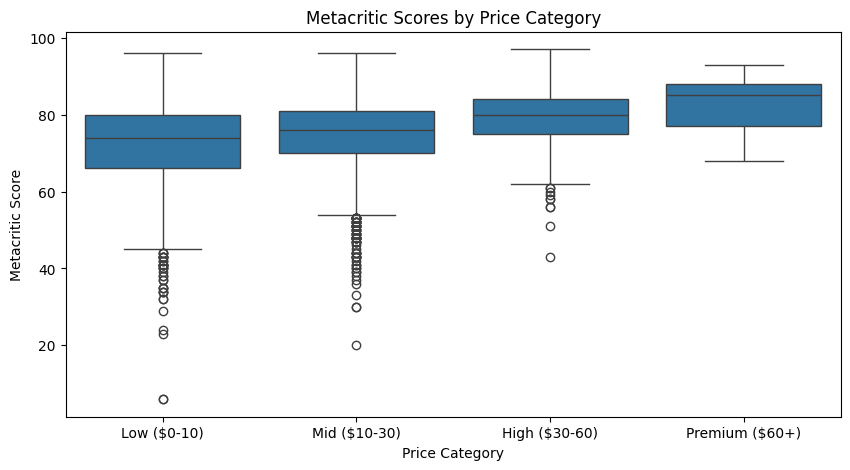

In [14]:
# Create price bins
steam_clean["price_category"] = pd.cut(
    steam_clean["mat_final_price"],
    bins=[0, 10, 30, 60, 100],
    labels=["Low ($0-10)", "Mid ($10-30)", "High ($30-60)", "Premium ($60+)"]
)

# Create boxplot
plt.figure(figsize=(10,5))
sns.boxplot(data=steam_clean, x="price_category", y="metacritic_score")

plt.title("Metacritic Scores by Price Category")
plt.xlabel("Price Category")
plt.ylabel("Metacritic Score")

plt.show()

### Q3: Come up with a another unique question. This question must use map() or apply()

# **Are cheaper games more likely to receive more recommendations?**

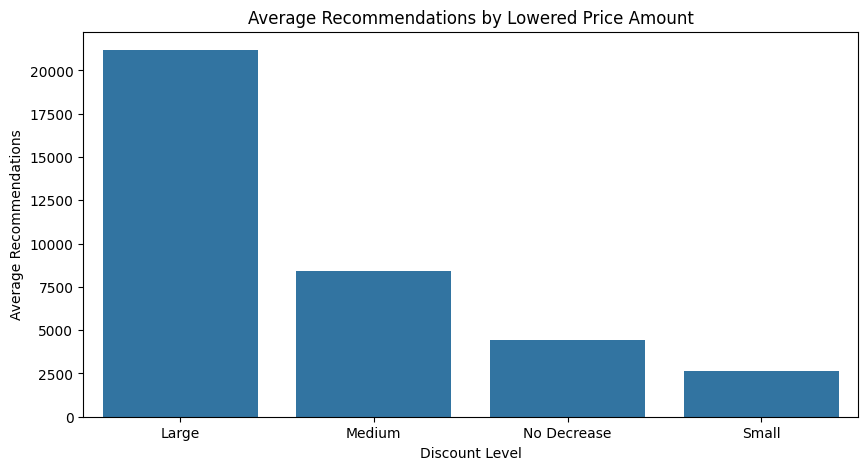

In [15]:
# Your code here . . .
steam_clean["discount_amount"] = steam_clean.apply(
    lambda row: row["mat_initial_price"] - row["mat_final_price"], axis=1
)

def discount_level(x):
    if x == 0:
        return "No Decrease"
    elif x < 10:
        return "Small"
    elif x < 30:
        return "Medium"
    else:
        return "Large"

steam_clean["discount_level"] = steam_clean["discount_amount"].apply(discount_level)

filtered_df = steam_clean.dropna(subset=["recommendations_total"])

avg_recs = filtered_df.groupby("discount_level")["recommendations_total"].mean().reset_index()

plt.figure(figsize=(10,5))
sns.barplot(data=avg_recs, x="discount_level", y="recommendations_total")

plt.title("Average Recommendations by Lowered Price Amount")
plt.xlabel("Discount Level")
plt.ylabel("Average Recommendations")

plt.show()

### Q4: Create an interactive plot
Create an interactive plot using plotly. Your plot can be a previously asked question or a new question, however explain how this interaction strengthen what you want to communicate with your audience.

We revisit **Q2** (Do higher priced games get better reviews?) with Plotly. A static boxplot shows the overall pattern, but this interactive version lets the audience **hover** to read exact quartiles, min/max, and how many games fall in each price band. **Zoom and pan** help compare one category’s spread to another without squinting at a fixed scale, which supports a clearer story about whether premium-priced games actually earn higher Metacritic scores.

In [2]:
import plotly.express as px

steam_clean["price_category"] = pd.cut(
    steam_clean["mat_final_price"],
    bins=[0, 10, 30, 60, 100],
    labels=["Low ($0-10)", "Mid ($10-30)", "High ($30-60)", "Premium ($60+)"],
)

plot_q4 = steam_clean.dropna(subset=["metacritic_score", "price_category"])

fig = px.box(
    plot_q4,
    x="price_category",
    y="metacritic_score",
    title="Metacritic scores by price category (interactive)",
    labels={
        "price_category": "Price category",
        "metacritic_score": "Metacritic score",
    },
    color="price_category",
)
fig.update_layout(
    showlegend=False,
    xaxis_title="Price category",
    yaxis_title="Metacritic score",
)
fig.show()

## Q5: Additional datasets and data processing
For the questions below you do not need to do the plotting if you have not found another complementary dataset. However, write the psuedocode of how you could go about answering the questions and sketches of what your visualization might be. Answer the following:

What additional datasets would you need to find or create to help strengthen your data?
How would you combine the dataset?
Do you need to reshape your data and how could you go about it?

---
Originally, we already tried filtering our dataset to only include the columns we thought would be relevant to predicting prices. However, now we realized that using columns such as genre and platform (which we filtered out) from the original dataset would provide more context for understanding how game prices differ across categories and systems. We would combine the datasets again using a shared field such as the game name or a unique game ID, then clean the merged data by checking for duplicates and missing values.

We would also want to create a new price range column (for now, we manually input the ranges) to organize games into categories such as Free, Low, Medium, and High. This would make the pricing data easier to interpret and compare across genres and platforms. Some reshaping may be needed if a game belongs to multiple genres or platforms, since those values may need to be split or standardized before analysis.

In [17]:
# # Your code here . . .
# ### Pseudocode
# ### Step 1: Load the cleaned dataset
# load steam_clean_under_100.csv into dataframe steam_clean

# ### Step 2: Load the original dataset that still contains extra columns
# load original steam dataset into dataframe steam_full
# (original dataset also has individual csv files per column, so we can use that as well
#  if we don't need many columns)

# ### Step 3: Select the extra columns that would strengthen the analysis
# keep columns such as:
# # - genre
# # - platform
# # - publisher
# # - developer

# ### Step 4: Merge the extra columns back into the cleaned dataset
# merge steam_clean with selected columns from steam_full
# using a shared key such as game name or game id

# ### Step 5: Clean merged results
# remove duplicate rows if needed
# check for missing genre/platform values
# standardize text formatting if needed

# ### Step 6: Create a new price range column
# for each game (based on what we used in P1):
#     if final price == 0:
#         label as "Free"
#     elif final price <= 10:
#         label as "Low"
#     elif final price <= 40:
#         label as "Medium"
#     else:
#         label as "High"

# ### Step 7: Group data for analysis
# group by genre and count games in each price range
# group by platform and count games in each price range
# group by publisher and count games in each price range
# gropu by developer and count games in each price range

# ### Step 8: Summarize findings
# compare which genres have more free or low-cost games
# compare whether certain platforms have more expensive games
# compare what certain publishers/developers tend to price their games at

# ### Step 9: Visualize results
# create a bar chart or stacked bar chart
# x-axis = genre, platform, publisher, or developer
# y-axis = number of games
# color = price range